Dataset Shape: (100, 4)
   user_id  movie_id  rating   timestamp
0        1         1       5  1678123456
1        1         2       4  1678123500
2        1         5       3  1678123600
3        1         8       5  1678123700
4        1        12       4  1678123800
User-Item Matrix Shape: (20, 12)


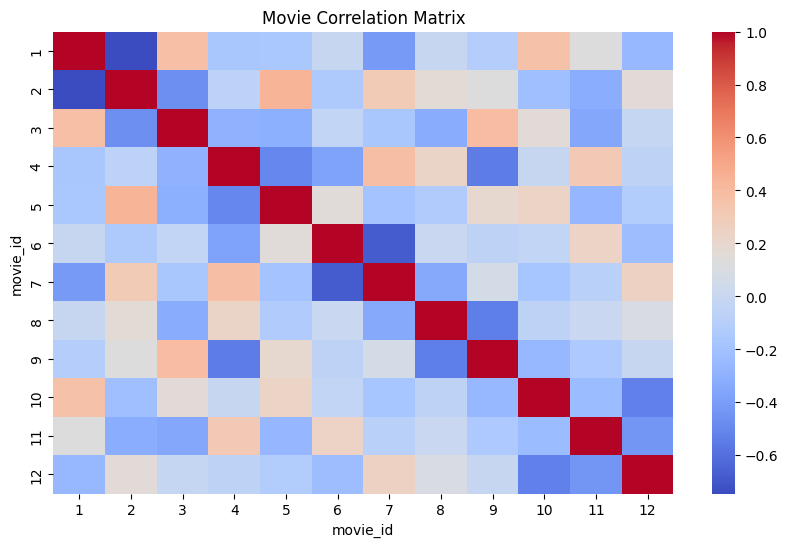

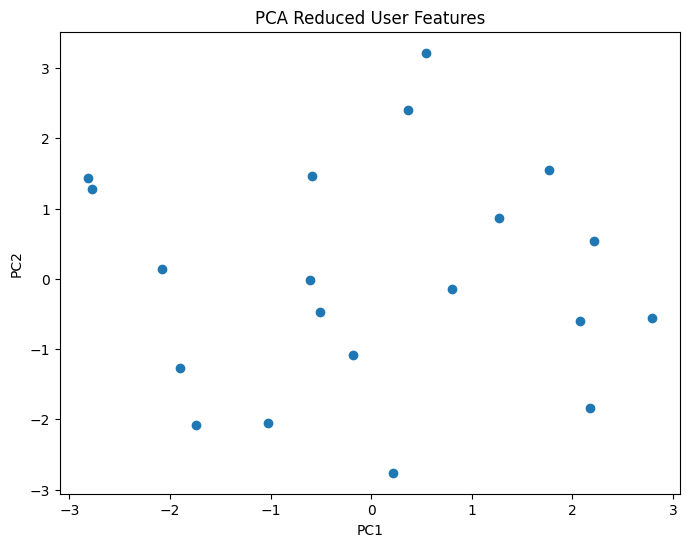

Cluster Distribution
4    6
1    5
2    5
3    2
0    2
Name: count, dtype: int64
Latent Feature Shape: (20, 10)
Gradient Boosting RMSE: 1.3106453885863931
Neural Network RMSE: 1.5124226243771695
Hybrid Model RMSE: 1.3564822121518236
Precision: 0.6363636363636364
Recall: 0.5384615384615384


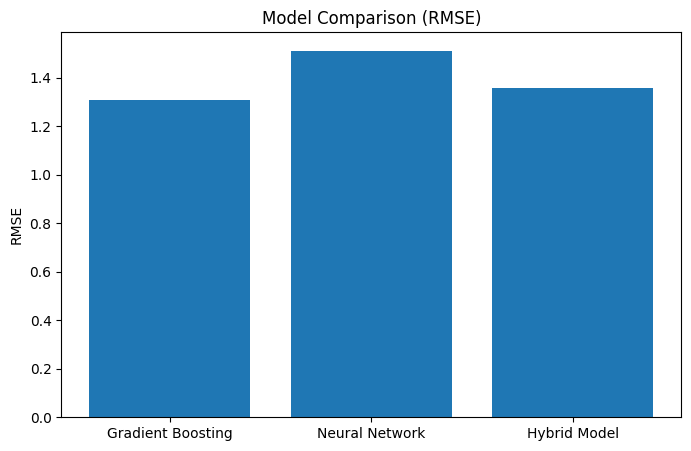

Comparative RMSE Scores
Gradient Boosting : 1.3106453885863931
Neural Network : 1.5124226243771695
Hybrid Model : 1.3564822121518236


In [ ]:
# =========================================
# Movie Recommendation System - Hybrid Model
# Dataset File Name: MovieLens_Dataset.xlsx
# =========================================

# Install required libraries
!pip install openpyxl scikit-learn seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, precision_score, recall_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# -------------------------------
# 1 Load Dataset
# -------------------------------

file_path = "MovieLens_Dataset.xlsx"

df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)
print(df.head())

# -------------------------------
# 2 Create User-Item Matrix
# -------------------------------

user_item_matrix = df.pivot_table(index='user_id', columns='movie_id', values='rating')

print("User-Item Matrix Shape:", user_item_matrix.shape)

# Fill missing values
user_item_matrix_filled = user_item_matrix.fillna(0)

# -------------------------------
# 3 Correlation Matrix
# -------------------------------

plt.figure(figsize=(10,6))
corr = user_item_matrix_filled.corr()

sns.heatmap(corr, cmap="coolwarm")
plt.title("Movie Correlation Matrix")
plt.show()

# -------------------------------
# 4 PCA Dimensionality Reduction
# -------------------------------

scaler = StandardScaler()
scaled_data = scaler.fit_transform(user_item_matrix_filled)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1])
plt.title("PCA Reduced User Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# -------------------------------
# 5 Unsupervised Learning - KMeans
# -------------------------------

kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

user_item_matrix_filled['cluster'] = clusters

print("Cluster Distribution")
print(pd.Series(clusters).value_counts())

# -------------------------------
# 6 Matrix Factorization (SVD)
# -------------------------------

# Changed n_components from 20 to 10 as n_features (movies) is 12.
svd = TruncatedSVD(n_components=10)

latent_matrix = svd.fit_transform(user_item_matrix_filled.drop('cluster',axis=1))

print("Latent Feature Shape:", latent_matrix.shape)

# -------------------------------
# 7 Prepare Data for Supervised Learning
# -------------------------------

X = df[['user_id','movie_id']]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 8 Gradient Boosting Model
# -------------------------------

gb_model = GradientBoostingRegressor()

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

print("Gradient Boosting RMSE:", gb_rmse)

# -------------------------------
# 9 Neural Network Model
# -------------------------------

nn_model = MLPRegressor(hidden_layer_sizes=(64,32),
                        max_iter=200,
                        random_state=42)

nn_model.fit(X_train, y_train)

nn_pred = nn_model.predict(X_test)

nn_rmse = np.sqrt(mean_squared_error(y_test, nn_pred))

print("Neural Network RMSE:", nn_rmse)

# -------------------------------
# 10 Hybrid Recommendation System
# Combine Cluster + Prediction
# -------------------------------

# Merge cluster info with original dataset
cluster_df = user_item_matrix_filled['cluster'].reset_index()

df_hybrid = df.merge(cluster_df, on="user_id")

X_hybrid = df_hybrid[['user_id','movie_id','cluster']]
y_hybrid = df_hybrid['rating']

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=42
)

hybrid_model = GradientBoostingRegressor()

hybrid_model.fit(X_train_h, y_train_h)

hybrid_pred = hybrid_model.predict(X_test_h)

hybrid_rmse = np.sqrt(mean_squared_error(y_test_h, hybrid_pred))

print("Hybrid Model RMSE:", hybrid_rmse)

# -------------------------------
# 11 Precision and Recall
# Convert ratings >=4 as liked movie
# -------------------------------

y_test_binary = (y_test >= 4).astype(int)
pred_binary = (gb_pred >= 4).astype(int)

precision = precision_score(y_test_binary, pred_binary)
recall = recall_score(y_test_binary, pred_binary)

print("Precision:", precision)
print("Recall:", recall)

# -------------------------------
# 12 Model Comparison
# -------------------------------

models = ['Gradient Boosting','Neural Network','Hybrid Model']
rmse_scores = [gb_rmse, nn_rmse, hybrid_rmse]

plt.figure(figsize=(8,5))
plt.bar(models, rmse_scores)
plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

print("Comparative RMSE Scores")
for m,r in zip(models,rmse_scores):
    print(m,":",r)